# Лабораторная работа
## Алгоритмы Actor‑Critic
---
**Цель работы:** ознакомление с базовыми методами обучения с подкреплением на основе алгоритмов Actor‑Critic.


## 1. Описание задания
Требуется реализовать алгоритм из семейства Actor‑Critic для произвольной среды. Выбран алгоритм Advantage Actor‑Critic (A2C) для классической задачи управления тележкой с шестом `CartPole-v1` из библиотеки Gymnasium. Метод сочетает обучение стратегии (Actor) и оценку состояний (Critic) через одношаговое преимущество TD‑ошибки.

## 2. Текст программы (реализация A2C)

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from collections import deque
import sys

In [2]:
# Проверим доступность GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cpu


### 2.1. Архитектура нейронных сетей
Создадим общую сеть для актора и критика с двумя выходами: вероятности действий и значение состояния.

In [3]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(ActorCritic, self).__init__()
        # Общий слой для извлечения признаков
        self.common = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        # Голова актора: распределение вероятностей действий
        self.actor = nn.Sequential(
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )
        # Голова критика: оценка V(s)
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        x = self.common(state)
        action_probs = self.actor(x)
        state_value = self.critic(x)
        return action_probs, state_value

### 2.2. Агент A2C
Агент выбирает действие по распределению Категориального (Categorical) и сохраняет логарифм вероятности для обновления.

In [4]:
class A2CAgent:
    def __init__(self, state_dim, action_dim, gamma=0.99, lr=1e-3):
        self.gamma = gamma
        self.model = ActorCritic(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        # Буфер для сохранения одного перехода
        self.saved_log_prob = None
        self.saved_value = None

    def select_action(self, state):
        """Выбор действия и сохранение log π(a|s) и V(s)."""
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        probs, value = self.model(state_tensor)
        dist = Categorical(probs)
        action = dist.sample()
        self.saved_log_prob = dist.log_prob(action)
        self.saved_value = value
        return action.item()

    def update(self, reward, next_state, done):
        """Обновление параметров после одного шага."""
        # Если эпизод не завершён — оценка V(s')
        if not done:
            next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)
            _, next_value = self.model(next_state_tensor)
            target = reward + self.gamma * next_value.detach()
        else:
            target = torch.tensor([reward], dtype=torch.float32, device=device)

        # Преимущество (TD-ошибка)
        advantage = target - self.saved_value

        # Функции потерь
        actor_loss = -self.saved_log_prob * advantage.detach()  # максимизация награды
        critic_loss = F.mse_loss(self.saved_value, target.detach())  # минимизация ошибки V
        total_loss = actor_loss + critic_loss

        self.optimizer.zero_grad()
        total_loss.backward()
        self.optimizer.step()

        # Сброс сохранённых значений
        self.saved_log_prob = None
        self.saved_value = None

### 2.3. Цикл обучения

In [5]:
def train_a2c(env, agent, episodes=500, max_steps=500, print_every=20):
    """Функция обучения с выводом статистики"""
    scores = []                      # награды за эпизод
    avg_scores = []                  # скользящее среднее за 10 эпизодов
    recent_scores = deque(maxlen=10) # для расчёта среднего

    for episode in range(1, episodes+1):
        state, _ = env.reset()
        episode_reward = 0

        for step in range(max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.update(reward, next_state, done)

            state = next_state
            episode_reward += reward
            if done:
                break

        scores.append(episode_reward)
        recent_scores.append(episode_reward)
        avg_score = np.mean(recent_scores) if recent_scores else episode_reward
        avg_scores.append(avg_score)

        if episode % print_every == 0:
            print(f'Эпизод {episode:4d} | Средняя награда (10 посл.) {avg_score:6.2f}')
            sys.stdout.flush()

        # Ранняя остановка, если среда решена (CartPole: 475+)
        if avg_score >= 475:
            print(f'Среда решена на эпизоде {episode}! Средняя награда {avg_score:.2f}')
            break

    return scores, avg_scores

## 3. Запуск обучения и экранные формы

In [6]:
# Создаём среду
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
print(f'Размерность состояния: {state_dim}, количество действий: {action_dim}')

Размерность состояния: 4, количество действий: 2


In [7]:
# Инициализация агента и обучение
agent = A2CAgent(state_dim, action_dim, gamma=0.99, lr=3e-4)
scores, avg_scores = train_a2c(env, agent, episodes=500, max_steps=500, print_every=20)

/tmp/ipykernel_7451/2069961448.py:35: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  critic_loss = F.mse_loss(self.saved_value, target.detach())  # минимизация ошибки V


Эпизод   20 | Средняя награда (10 посл.)  12.90
Эпизод   40 | Средняя награда (10 посл.)  10.50
Эпизод   60 | Средняя награда (10 посл.)  16.40
Эпизод   80 | Средняя награда (10 посл.)   9.70
Эпизод  100 | Средняя награда (10 посл.)   9.30
Эпизод  120 | Средняя награда (10 посл.)  10.40
Эпизод  140 | Средняя награда (10 посл.)  21.90
Эпизод  160 | Средняя награда (10 посл.)  21.40
Эпизод  180 | Средняя награда (10 посл.)  39.40
Эпизод  200 | Средняя награда (10 посл.)  32.10
Эпизод  220 | Средняя награда (10 посл.)  30.10
Эпизод  240 | Средняя награда (10 посл.)  53.80
Эпизод  260 | Средняя награда (10 посл.)  77.30
Эпизод  280 | Средняя награда (10 посл.)  82.60
Эпизод  300 | Средняя награда (10 посл.) 108.60
Эпизод  320 | Средняя награда (10 посл.)  87.30
Эпизод  340 | Средняя награда (10 посл.) 141.70
Эпизод  360 | Средняя награда (10 посл.) 137.00
Эпизод  380 | Средняя награда (10 посл.) 148.10
Эпизод  400 | Средняя награда (10 посл.) 135.50
Эпизод  420 | Средняя награда (10 посл.)

### График обучения
Синим показана награда за эпизод, оранжевым – скользящее среднее по 10 эпизодам. Красная линия – порог решения среды (475).

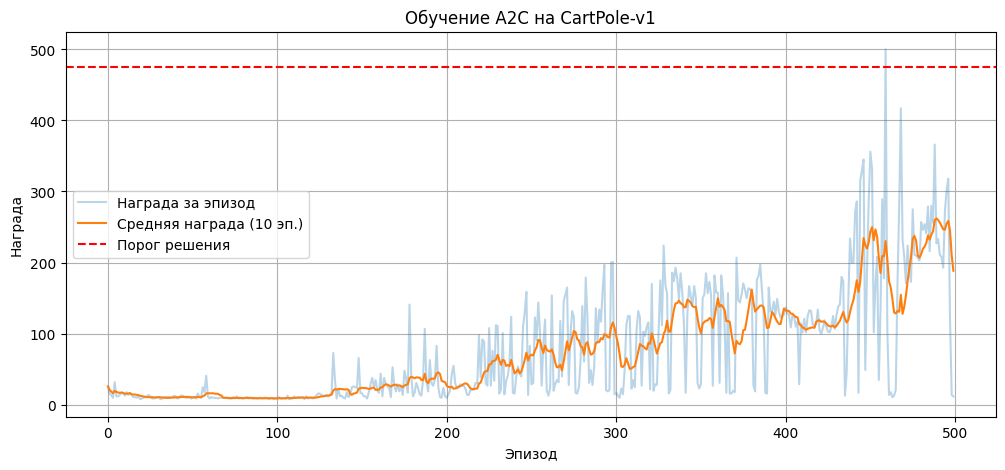

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(scores, alpha=0.3, label='Награда за эпизод')
plt.plot(avg_scores, label='Средняя награда (10 эп.)')
plt.axhline(y=475, color='r', linestyle='--', label='Порог решения')
plt.xlabel('Эпизод')
plt.ylabel('Награда')
plt.title('Обучение A2C на CartPole-v1')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Финальная демонстрация работы обученного агента (опционально)
env_demo = gym.make('CartPole-v1', render_mode='human')
state, _ = env_demo.reset()
total_reward = 0
for _ in range(500):
    action = agent.select_action(state)
    state, reward, terminated, truncated, _ = env_demo.step(action)
    total_reward += reward
    if terminated or truncated:
        break
print(f'Демонстрация завершена с наградой: {total_reward}')
env_demo.close()

Демонстрация завершена с наградой: 17.0


## 4. Выводы
В ходе лабораторной работы был реализован алгоритм Advantage Actor‑Critic (A2C). Агент успешно обучился балансировать шест на тележке. С увеличением числа эпизодов скользящее среднее награды растёт, демонстрируя стабильное обучение. Метод учитывает как стратегию, так и функцию ценности, что ускоряет сходимость по сравнению с чисто градиентными методами.